# 03. Các Mô Hình Deep Learning

Huấn luyện CNN, LSTM và SimpleRNN trên raw URL string (char-level tokenization).  
Khác với notebook 02, các model ở đây học trực tiếp từ chuỗi ký tự thay vì 59 engineered features.

**Models:** LSTM · CNN · SimpleRNN

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score,
                              precision_score, recall_score)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

df = pd.read_csv('../final_dataset_with_all_features_v3.1.csv')
df_seq = df[['url', 'label']].copy()

MAX_VOCAB = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, char_level=True)
tokenizer.fit_on_texts(df_seq['url'])

X_seq = pad_sequences(tokenizer.texts_to_sequences(df_seq['url']),
                      maxlen=MAX_LEN, padding='post', truncating='post')
y_seq = df_seq['label'].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

print(f"X_train_seq: {X_train_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")

X_train_seq: (520952, 200)
X_test_seq:  (130239, 200)


## 2. Hàm Đánh Giá Chung

In [3]:
def evaluate_model(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall   : {rec*100:.2f}%")
    print(f"F1-Score : {f1*100:.2f}%")
    print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Defacement','Phishing','Malware'],
                yticklabels=['Benign','Defacement','Phishing','Malware'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'Mô hình': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

results = []

## 3. LSTM

c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 378s 231ms/step - accuracy: 0.6578 - loss: 0.9882 - val_accuracy: 0.6621 - val_loss: 0.9787
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 1927s 1s/step - accuracy: 0.8451 - loss: 0.4416 - val_accuracy: 0.8713 - val_loss: 0.3517
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 399s 245ms/step - accuracy: 0.9053 - loss: 0.2618 - val_accuracy: 0.9166 - val_loss: 0.2301
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 426s 261ms/step - accuracy: 0.9165 - loss: 0.2337 - val_accuracy: 0.8190 - val_loss: 0.4844
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 341s 209ms/step - accuracy: 0.8996 - loss: 0.2831 - val_accuracy: 0.9170 - val_loss: 0.2323
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 419s 257ms/step - accuracy: 0.9209 - loss: 0.2204 - val_accuracy: 0.9251 - val_loss: 0.2073
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 435s 267ms/step - accuracy: 0.9278 - loss: 0.2003 - val_accuracy: 0.9322 - val_loss: 0.1875
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 2974s 2s/step - accura

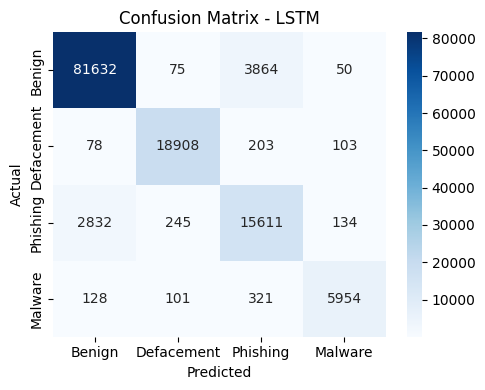

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

lstm_model.fit(X_train_seq, y_train_seq,
               epochs=10, batch_size=256,
               validation_split=0.2, verbose=1)

y_pred_lstm = lstm_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('LSTM', y_test_seq, y_pred_lstm))

## 4. CNN

Dùng `Conv1D` để phát hiện các pattern cục bộ trong chuỗi ký tự phù hợp với URL vì các dấu hiệu độc hại thường nằm ở đoạn ngắn như `/login`, `.exe`, `@`.

c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9015 - loss: 0.2688 - val_accuracy: 0.9387 - val_loss: 0.1723
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 90s 55ms/step - accuracy: 0.9421 - loss: 0.1587 - val_accuracy: 0.9477 - val_loss: 0.1447
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9510 - loss: 0.1330 - val_accuracy: 0.9531 - val_loss: 0.1293
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9559 - loss: 0.1195 - val_accuracy: 0.9536 - val_loss: 0.1254
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9589 - loss: 0.1101 - val_accuracy: 0.9582 - val_loss: 0.1130
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.9610 - loss: 0.1031 - val_accuracy: 0.9598 - val_loss: 0.1117
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9628 - loss: 0.0985 - val_accuracy: 0.9571 - val_loss: 0.1139
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 124s 76ms/step - accuracy: 0.9647 

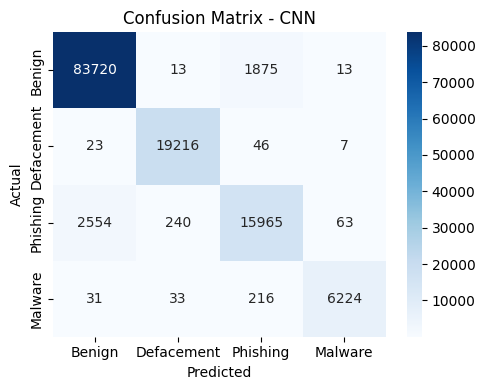

In [5]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.fit(X_train_seq, y_train_seq,
              epochs=10, batch_size=256,
              validation_split=0.2, verbose=1)

y_pred_cnn = cnn_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('CNN', y_test_seq, y_pred_cnn))

## 5. SimpleRNN

Epoch 1/10


c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1628/1628 ━━━━━━━━━━━━━━━━━━━━ 135s 82ms/step - accuracy: 0.6574 - loss: 0.9796 - val_accuracy: 0.6608 - val_loss: 0.9581
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 127s 78ms/step - accuracy: 0.6672 - loss: 0.9427 - val_accuracy: 0.7506 - val_loss: 0.6681
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 117s 72ms/step - accuracy: 0.7514 - loss: 0.6665 - val_accuracy: 0.8029 - val_loss: 0.5510
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 118s 73ms/step - accuracy: 0.7976 - loss: 0.5562 - val_accuracy: 0.7206 - val_loss: 0.7112
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 3441s 2s/step - accuracy: 0.7535 - loss: 0.6724 - val_accuracy: 0.7528 - val_loss: 0.6584
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - accuracy: 0.7602 - loss: 0.6493 - val_accuracy: 0.7319 - val_loss: 0.6892
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 93s 57ms/step - accuracy: 0.7468 - loss: 0.6793 - val_accuracy: 0.7547 - val_loss: 0.6551
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 125s 77ms/step - accuracy: 0.7601 - loss:

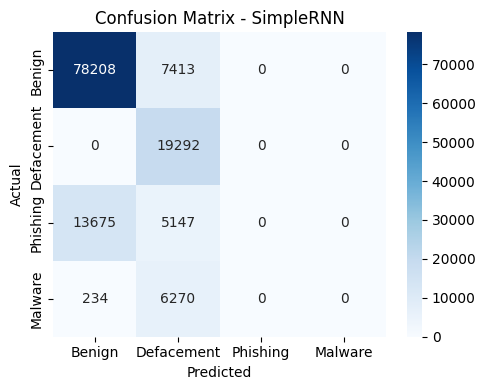

In [6]:
from tensorflow.keras.layers import SimpleRNN

rnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

rnn_model.fit(X_train_seq, y_train_seq,
              epochs=10, batch_size=256,
              validation_split=0.2, verbose=1)

y_pred_rnn = rnn_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('SimpleRNN', y_test_seq, y_pred_rnn))

## 6. So Sánh Các Mô Hình Deep Learning

In [13]:
def evaluate_model(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    return {'Mô hình': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

print("=== BẢNG SO SÁNH CÁC MÔ HÌNH DEEP LEARNING ===")
print(df_dl_results.to_string())

=== BẢNG SO SÁNH CÁC MÔ HÌNH DEEP LEARNING ===
     Mô hình Accuracy Precision  Recall F1-Score
1        CNN   96.07%    96.02%  96.07%   96.04%
2       LSTM   93.75%    93.92%  93.75%   93.82%
3  SimpleRNN   74.86%    63.31%  74.86%   67.81%
